# Reinforcement learning
RL involves an agent interacting with an environment to maximize a reward. Key components:

- State (S): The agent's situation (e.g., position in the grid).
- Action (A): Choices the agent can make (e.g., move up, down, left, right).
- Reward (R): Feedback from the environment (e.g., +1 for reaching the goal).
- Policy (π): The agent's strategy for choosing actions.
- Q-Value: The expected future reward for taking an action in a state.

We'll use Q-Learning, a simple RL algorithm that updates a Q-table based on rewards.

## Grid World environment

The environment is a 4×4 grid. The agent starts at the top-left corner `(0,0)` and must navigate to the goal at the bottom-right corner `(3,3)`.

- The agent receives a reward of `+1` only when it reaches the goal; all other steps give `0`.
- The Q-table has shape `(rows, cols, 4)` — one Q-value for every `(state, action)` pair, initialized to zero.
- `step()` applies an action, clips movement to grid boundaries, and returns `(next_state, reward, done)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 4
GOAL = (GRID_SIZE - 1, GRID_SIZE - 1)

# Q-table: shape (rows, cols, actions) — one Q-value per (state, action) pair
q_table = np.zeros((GRID_SIZE, GRID_SIZE, 4))

# Reward grid: +1 at goal, 0 everywhere else
rewards = np.zeros((GRID_SIZE, GRID_SIZE))
rewards[GOAL] = 1

actions = ['up', 'down', 'left', 'right']
action_to_idx = {a: i for i, a in enumerate(actions)}

def step(state, action):
    row, col = state
    if action == 'up':
        row = max(row - 1, 0)
    elif action == 'down':
        row = min(row + 1, GRID_SIZE - 1)
    elif action == 'left':
        col = max(col - 1, 0)
    elif action == 'right':
        col = min(col + 1, GRID_SIZE - 1)
    next_state = (row, col)
    reward = rewards[row, col]
    done = next_state == GOAL
    return next_state, reward, done

## Q-Learning

Q-Learning is a **model-free** RL algorithm — the agent learns purely from experience without needing to know the environment's dynamics.

The Q-table is updated after each step using the **Bellman equation**:

```
Q(s, a) ← Q(s, a) + α · [r + γ · max_a' Q(s', a') - Q(s, a)]
```

The term `r + γ · max_a' Q(s', a') - Q(s, a)` is the **TD error** — the difference between what was expected and what actually happened.

- `α` (alpha): Learning rate — how much new experience overwrites old estimates.
- `γ` (gamma): Discount factor — how much future rewards are valued. At `0.9`, a reward 10 steps away is worth `0.9^10 ≈ 0.35` of its face value.
- `ε` (epsilon): Exploration rate — with probability `ε` the agent picks a **random** action (explore); otherwise it picks the highest Q-value action (exploit). This trade-off is essential early in training when Q-values are unreliable.

In [2]:
alpha = 0.1    # Learning rate
gamma = 0.9    # Discount factor
epsilon = 0.1  # Exploration rate
episodes = 1000

episode_rewards = []

for episode in range(episodes):
    state = (0, 0)
    done = False
    total_reward = 0

    while not done:
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = np.random.choice(actions)  # Explore
        else:
            action_idx = np.argmax(q_table[state[0], state[1]])  # Exploit
            action = actions[action_idx]

        next_state, reward, done = step(state, action)

        # Bellman update
        action_idx = action_to_idx[action]
        old_q = q_table[state[0], state[1], action_idx]
        next_max_q = np.max(q_table[next_state[0], next_state[1]])
        q_table[state[0], state[1], action_idx] = old_q + alpha * (reward + gamma * next_max_q - old_q)

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)

print("Training complete!")

Training complete!


### Training progress

Plot the reward per episode (smoothed) to confirm the agent is converging. Once training works, most episodes should end with a reward of `1.0` (reached the goal).

## Test the learned policy

Run the agent **greedily** (always pick the highest Q-value action, no exploration) from start to goal and visualize two things:

1. **Path**: the sequence of cells the agent visits
2. **Max Q-value heatmap**: the highest Q-value in each cell across all actions — higher values near the goal show the agent has learned the value gradient propagating backward from the reward

Learned path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (3, 3)]


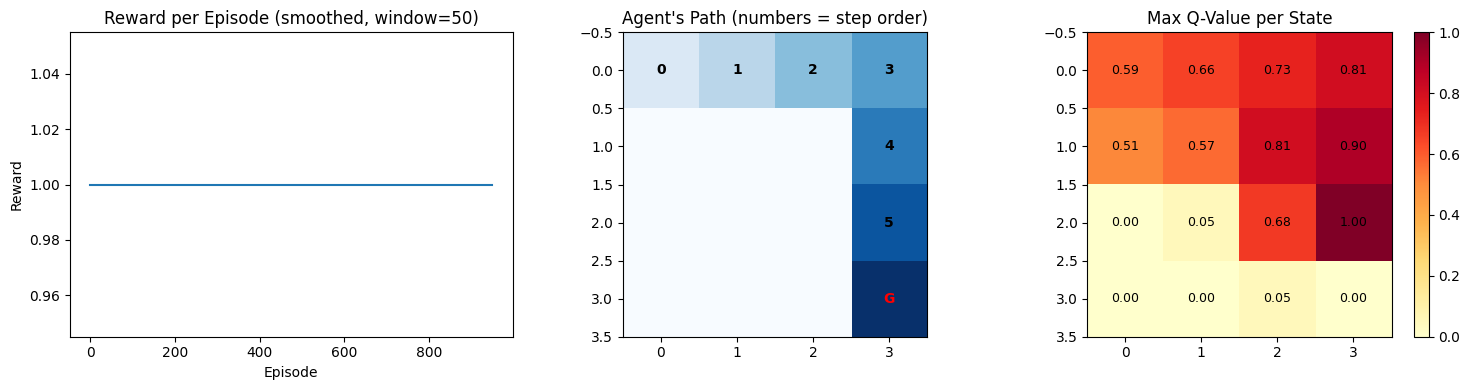

In [3]:
def test_policy(max_steps=100):
    state = (0, 0)
    path = [state]
    done = False
    for _ in range(max_steps):
        if done:
            break
        action_idx = np.argmax(q_table[state[0], state[1]])
        action = actions[action_idx]
        next_state, reward, done = step(state, action)
        path.append(next_state)
        state = next_state
    return path

path = test_policy()
print("Learned path:", path)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training progress
window = 50
smoothed = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')
axes[0].plot(smoothed)
axes[0].set_title(f'Reward per Episode (smoothed, window={window})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')

# Agent path
path_grid = np.zeros((GRID_SIZE, GRID_SIZE))
for step_num, (row, col) in enumerate(path):
    path_grid[row, col] = step_num + 1
axes[1].imshow(path_grid, cmap='Blues')
axes[1].set_title("Agent's Path (numbers = step order)")
for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):
        if (row, col) in path:
            label = 'G' if (row, col) == GOAL else str(path.index((row, col)))
            color = 'red' if (row, col) == GOAL else 'black'
            axes[1].text(col, row, label, ha='center', va='center', color=color, fontweight='bold')

# Max Q-value heatmap
max_q = np.max(q_table, axis=2)
im = axes[2].imshow(max_q, cmap='YlOrRd')
axes[2].set_title('Max Q-Value per State')
for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):
        axes[2].text(col, row, f'{max_q[row, col]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()